# Feature Selection 

This notebook walks through **From creating the features till selecting the model**   

## Data loading

In [2]:
# Importing Libraries
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore")


print(" Libraries imported successfully")
# Load dataset
file_path = "Flight Delay Dataset.csv"
df= pd.read_csv(file_path)

print(" Data loaded")
print("Shape (rows, columns):", df.shape)
df.head()

 Libraries imported successfully
 Data loaded
Shape (rows, columns): (148052, 19)


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEP_TIME,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,DISTANCE_GROUP
0,2017,3,7,11,2,7/11/2017,DL,LIT,"Little Rock, AR",AR,ATL,"Atlanta, GA",GA,538,757,-11.0,64,453,2
1,2018,1,3,14,3,3/14/2018,DL,BOS,"Boston, MA",MA,ATL,"Atlanta, GA",GA,1829,2108,-23.0,127,946,4
2,2017,4,11,12,7,11/12/2017,WN,ATL,"Atlanta, GA",GA,DAL,"Dallas, TX",TX,1345,1451,-9.0,106,721,3
3,2017,3,8,22,2,8/22/2017,EV,ATL,"Atlanta, GA",GA,HPN,"White Plains, NY",NY,1158,1408,-21.0,113,780,4
4,2018,1,3,2,5,3/2/2018,DL,MSY,"New Orleans, LA",LA,ATL,"Atlanta, GA",GA,522,737,-19.0,59,425,2


## Target Variable - `ARR_DELAY` as we need to predict will the flight delay?
**Thought process**
- How do I want to define a ‘delay’ for this product? Is a flight 5 minutes late really a problem, or should I focus on 15+ minutes?”
- “From a user’s perspective, is there a difference between being `15 minutes` late vs `1 hours` late? Should I create delay severity buckets (e.g., on-time, mildly delayed, heavily delayed)?”
- “What label definition best matches the business goal: warning people about serious delays rather than tiny schedule noise"

In [3]:
'''
Divide the category - helps in categorical selection tell us severaity of the delay
'''
df = df.dropna(subset=["ARR_DELAY"])
# Define "delayed" as ARR_DELAY > 15 minutes (industry standard)
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

#: Multi-class Classification
df['DELAY_CATEGORY'] = pd.cut(df['ARR_DELAY'], 
                               bins=[-np.inf, 0, 15, 60, np.inf],
                               labels=['Early/OnTime', 'Minor', 'Moderate', 'Severe'])



print("Target Variable Distribution:")
print(df['IS_DELAYED'].value_counts())
print(f"\nDelay Rate: {df['IS_DELAYED'].mean():.2%}")
print(df['DELAY_CATEGORY'])

print('testing')
print(df.shape)

Target Variable Distribution:
IS_DELAYED
0    126673
1     21312
Name: count, dtype: int64

Delay Rate: 14.40%
0         Early/OnTime
1         Early/OnTime
2         Early/OnTime
3         Early/OnTime
4         Early/OnTime
              ...     
148047    Early/OnTime
148048           Minor
148049    Early/OnTime
148050    Early/OnTime
148051    Early/OnTime
Name: DELAY_CATEGORY, Length: 147985, dtype: category
Categories (4, object): ['Early/OnTime' < 'Minor' < 'Moderate' < 'Severe']
testing
(147985, 21)


## Creating Features


**Time-of-day and schedule**
- Do flights at certain times of day tend to get delayed more (e.g., evening waves, late-night stack-ups)?”
- “Is the exact hour of departure predictive of delays (rush hours vs quiet hours)?”
- "Is it holiday season ?"
- “Do weekend flights behave differently from weekday flights in terms of delays?
- “Is the exact minute important, or is it enough to know whether it’s morning vs evening? Should I group hours into broader time periods to capture congestion patterns?”
- “If I tell a user ‘evening flights on this route are risky’, what feature do I need in the data so my model can learn that pattern?”

In [4]:
# Convert FL_DATE to datetime

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# ========== Time-based Features ==========
df['HOUR'] = df['DEP_TIME'] // 100  # Extract hour from HHMM format
df['MINUTE'] = df['DEP_TIME'] % 100

# Create time period categories
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['TIME_PERIOD'] = df['HOUR'].apply(get_time_period)

# Weekend indicator
df['IS_WEEKEND'] = (df['DAY_OF_WEEK'].isin([6, 7])).astype(int)

# Holiday/Peak travel indicators (customize based on your EDA findings)
df['IS_HOLIDAY_SEASON'] = ((df['MONTH'] == 12) | 
                            (df['MONTH'] == 7) | 
                            ((df['MONTH'] == 11) & (df['DAY_OF_MONTH'] >= 20))).astype(int)

# Season Indicator
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['SEASON'] = df['MONTH'].apply(get_season)

print("Temporal features created")


Temporal features created


**Routes taken (Geography)**
- some origin–destination pairs systematically experience more delays than others?”
- “Is route congestion itself a signal? Are highly trafficked routes more prone to delays?”
- Does it matter which carrier is operating which route? For example, Airline A on NYC–LAX might be more delay-prone than Airline B on the same route.”
- Do in-state flights behave differently from cross-state or longer flights in terms of delays?”

In [5]:
# ========== Route Features ==========
df['ROUTE'] = df['ORIGIN'] + '_' + df['DEST']

# Route popularity by uisng flight frequency
route_counts = df['ROUTE'].value_counts()
df['ROUTE_FREQUENCY'] = df['ROUTE'].map(route_counts)

# Same state flight indicator
df['IS_SAME_STATE'] = (df['ORIGIN_STATE_ABR'] == df['DEST_STATE_ABR']).astype(int)

# Create the combined category string
df['ROUTE_KEY'] = df['UNIQUE_CARRIER'] + '_' + df['ORIGIN'] + '_' + df['DEST']

print("Route features created")


Route features created


**History of Past Flight** : `highly important to understand the history`
- Is a carrier’s past reliability a good predictor of future delays? For example, if Airline X has historically high delay times
- “Do some airports (origins or destinations) consistently have higher average delays?”
- “Do specific routes have a track record of being delay-prone?”
- “Is the combination of carrier + route important? Maybe Airline A is fine overall, but terrible on one particular route.”
- “Are there systematic time patterns, like Monday 7 a.m. vs Friday evening, that repeat over time?”

**Important Question - `“In real life, I only know the past, not the future. How do I make sure my model isn’t accidentally using future delay information to predict the past?”`**

`With history comes leakage -` 
`We cant have data randomly split as 2018 seen trained data cant act input for 2017 test data`


**I have Created historical aggregation features (mean, std, median delay and flight counts) per carrier, airport, route, and carrier–route combinations helping me avoid leakage**

In [6]:
# ========== Historical Delay Features ==========
# Sort by date to avoid data leakage
df = df.sort_values('FL_DATE').reset_index(drop=True)

# Function to create lag features safely (avoiding data leakage)
def create_historical_features(df, group_cols, value_col='ARR_DELAY', prefix=''):
    """
    Creates rolling statistics for historical delay patterns
    """
    # Group and calculate historical metrics (excluding current row)
    historical_stats = df.groupby(group_cols)[value_col].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('median', 'median'),
        ('count', 'count')
    ]).reset_index()
    
    # Rename columns
    historical_stats.columns = group_cols + [
        f'{prefix}HIST_DELAY_MEAN',
        f'{prefix}HIST_DELAY_STD',
        f'{prefix}HIST_DELAY_MEDIAN',
        f'{prefix}HIST_FLIGHT_COUNT'
    ]
    
    return historical_stats

# Create training set (first 80% chronologically) for computing historical stats
split_date = df['FL_DATE'].quantile(0.8)
train_mask = df['FL_DATE'] < split_date

# Compute historical statistics on training data only
train_df = df[train_mask].copy()

# 1. Carrier historical performance
carrier_hist = create_historical_features(train_df, ['UNIQUE_CARRIER'], prefix='CARRIER_')
df = df.merge(carrier_hist, on='UNIQUE_CARRIER', how='left')

# 2. Origin airport historical performance
origin_hist = create_historical_features(train_df, ['ORIGIN'], prefix='ORIGIN_')
df = df.merge(origin_hist, on='ORIGIN', how='left')

# 3. Destination airport historical performance
dest_hist = create_historical_features(train_df, ['DEST'], prefix='DEST_')
df = df.merge(dest_hist, on='DEST', how='left')

# 4. Route historical performance
route_hist = create_historical_features(train_df, ['ROUTE'], prefix='ROUTE_')
df = df.merge(route_hist, on='ROUTE', how='left')

# 5. Carrier-Route combination
carrier_route_hist = create_historical_features(train_df, ['UNIQUE_CARRIER', 'ROUTE'], prefix='CARRIER_ROUTE_')
df = df.merge(carrier_route_hist, on=['UNIQUE_CARRIER', 'ROUTE'], how='left')

# 6. Time-based patterns (e.g., delays by hour, day of week)
time_hist = create_historical_features(train_df, ['HOUR', 'DAY_OF_WEEK'], prefix='TIME_')
df = df.merge(time_hist, on=['HOUR', 'DAY_OF_WEEK'], how='left')

print("Historical aggregation features created")


Historical aggregation features created


## Synthesised data check

In [7]:
df.head(2)

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,...,ROUTE_HIST_DELAY_MEDIAN,ROUTE_HIST_FLIGHT_COUNT,CARRIER_ROUTE_HIST_DELAY_MEAN,CARRIER_ROUTE_HIST_DELAY_STD,CARRIER_ROUTE_HIST_DELAY_MEDIAN,CARRIER_ROUTE_HIST_FLIGHT_COUNT,TIME_HIST_DELAY_MEAN,TIME_HIST_DELAY_STD,TIME_HIST_DELAY_MEDIAN,TIME_HIST_FLIGHT_COUNT
0,2017,2,5,1,1,2017-05-01,EV,ATL,"Atlanta, GA",GA,...,-7.0,326.0,5.033784,36.692585,-8.5,148.0,4.408966,35.600220,-7.0,1093.0
1,2017,2,5,1,1,2017-05-01,DL,MLB,"Melbourne, FL",FL,...,-10.0,249.0,-2.259414,40.459748,-10.0,239.0,-7.270781,27.047033,-10.0,794.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147985 entries, 0 to 147984
Data columns (total 55 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   YEAR                             147985 non-null  int64         
 1   QUARTER                          147985 non-null  int64         
 2   MONTH                            147985 non-null  int64         
 3   DAY_OF_MONTH                     147985 non-null  int64         
 4   DAY_OF_WEEK                      147985 non-null  int64         
 5   FL_DATE                          147985 non-null  datetime64[ns]
 6   UNIQUE_CARRIER                   147985 non-null  object        
 7   ORIGIN                           147985 non-null  object        
 8   ORIGIN_CITY_NAME                 147985 non-null  object        
 9   ORIGIN_STATE_ABR                 147985 non-null  object        
 10  DEST                             147985 non-

In [9]:

threshold = len(df)  # the minimum number of non-null values I expect


non_null_counts = df.notna().sum()


cols_below_threshold = non_null_counts[non_null_counts < threshold]

print(f"Total rows (for reference): {len(df)}\n")

cols_below_threshold = non_null_counts[non_null_counts < threshold]
if cols_below_threshold.empty:
    print("No columns are missing data", threshold, "non-null values.")
else:
    print(cols_below_threshold)

Total rows (for reference): 147985

ORIGIN_HIST_DELAY_MEAN             147983
ORIGIN_HIST_DELAY_STD              147976
ORIGIN_HIST_DELAY_MEDIAN           147983
ORIGIN_HIST_FLIGHT_COUNT           147983
DEST_HIST_DELAY_STD                147979
ROUTE_HIST_DELAY_MEAN              147931
ROUTE_HIST_DELAY_STD               147877
ROUTE_HIST_DELAY_MEDIAN            147931
ROUTE_HIST_FLIGHT_COUNT            147931
CARRIER_ROUTE_HIST_DELAY_MEAN      147551
CARRIER_ROUTE_HIST_DELAY_STD       147262
CARRIER_ROUTE_HIST_DELAY_MEDIAN    147551
CARRIER_ROUTE_HIST_FLIGHT_COUNT    147551
TIME_HIST_DELAY_MEAN               147983
TIME_HIST_DELAY_STD                147977
TIME_HIST_DELAY_MEDIAN             147983
TIME_HIST_FLIGHT_COUNT             147983
dtype: int64


- As we have missing data

In [10]:
hist_cols = [col for col in df.columns if 'HIST_' in col]
for col in hist_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values handled")

Missing values handled


In [11]:
threshold = len(df)  # the minimum number of non-null values I expect


non_null_counts = df.notna().sum()


cols_below_threshold = non_null_counts[non_null_counts < threshold]

print(f"Total rows (for reference): {len(df)}\n")

cols_below_threshold = non_null_counts[non_null_counts < threshold]
if cols_below_threshold.empty:
    print("No columns are missing data", threshold, "non-null values.")
else:
    print(cols_below_threshold)

Total rows (for reference): 147985

No columns are missing data 147985 non-null values.


In [12]:
df.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR',
       'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEP_TIME', 'ARR_TIME',
       'ARR_DELAY', 'AIR_TIME', 'DISTANCE', 'DISTANCE_GROUP', 'IS_DELAYED',
       'DELAY_CATEGORY', 'HOUR', 'MINUTE', 'TIME_PERIOD', 'IS_WEEKEND',
       'IS_HOLIDAY_SEASON', 'SEASON', 'ROUTE', 'ROUTE_FREQUENCY',
       'IS_SAME_STATE', 'ROUTE_KEY', 'CARRIER_HIST_DELAY_MEAN',
       'CARRIER_HIST_DELAY_STD', 'CARRIER_HIST_DELAY_MEDIAN',
       'CARRIER_HIST_FLIGHT_COUNT', 'ORIGIN_HIST_DELAY_MEAN',
       'ORIGIN_HIST_DELAY_STD', 'ORIGIN_HIST_DELAY_MEDIAN',
       'ORIGIN_HIST_FLIGHT_COUNT', 'DEST_HIST_DELAY_MEAN',
       'DEST_HIST_DELAY_STD', 'DEST_HIST_DELAY_MEDIAN',
       'DEST_HIST_FLIGHT_COUNT', 'ROUTE_HIST_DELAY_MEAN',
       'ROUTE_HIST_DELAY_STD', 'ROUTE_HIST_DELAY_MEDIAN',
       'ROUTE_HIST_FLIGHT_COUNT', 'CARRIER_ROUTE_HIST_DELAY_MEAN',
       'CARRI

- Dataframe has = [
    # Carrier-level stats
    'CARRIER_HIST_DELAY_MEAN',
    'CARRIER_HIST_DELAY_STD',
    'CARRIER_HIST_DELAY_MEDIAN',
    'CARRIER_HIST_FLIGHT_COUNT',
    
    # Origin-level stats
    'ORIGIN_HIST_DELAY_MEAN',
    'ORIGIN_HIST_DELAY_STD',
    'ORIGIN_HIST_DELAY_MEDIAN',
    'ORIGIN_HIST_FLIGHT_COUNT',
    
    # Destination-level stats
    'DEST_HIST_DELAY_MEAN',
    'DEST_HIST_DELAY_STD',
    'DEST_HIST_DELAY_MEDIAN',
    'DEST_HIST_FLIGHT_COUNT',
    
    # Route-level stats
    'ROUTE_HIST_DELAY_MEAN',
    'ROUTE_HIST_DELAY_STD',
    'ROUTE_HIST_DELAY_MEDIAN',
    'ROUTE_HIST_FLIGHT_COUNT',
    
    # Carrier-route combo (if you created them)
    'CARRIER_ROUTE_HIST_DELAY_MEAN',
    'CARRIER_ROUTE_HIST_DELAY_STD',
    'CARRIER_ROUTE_HIST_DELAY_MEDIAN',
    'CARRIER_ROUTE_HIST_FLIGHT_COUNT',
    
    # Time-window stats like hour x day_of_week
    'TIME_HIST_DELAY_MEAN',
    'TIME_HIST_DELAY_STD',
    'TIME_HIST_DELAY_MEDIAN',
    'TIME_HIST_FLIGHT_COUNT'
]

## Columns to Drop for training the models
* We need to drop few columns as they are **pure identifiers**, or are **not useful for prediction**. Keeping them would either would create sparse my metrics unrealistically or just add noise to the model.

- I chose these columns `["ARR_TIME", "AIR_TIME"]` because they contain information only available after the flight has operated, so keeping them would leak future/label information into the model.

- As for `RAW_REDUNDANT_COLS` I chose these columns because I've already transformed their information into cleaner, more predictive features, so they are now redundant and can be safely dropped.

In [13]:
df_model = df.copy()

In [14]:
#Drop future / leaky columns

LEAKY_COLS = [
    "ARR_TIME",
    "AIR_TIME",
]

cols_to_drop = [c for c in LEAKY_COLS if c in df_model.columns]
RAW_REDUNDANT_COLS = [
    "FL_DATE",
    "DEP_TIME",
    "DISTANCE_GROUP",
    "MINUTE",
    "QUARTER",
]

cols_to_drop = [c for c in RAW_REDUNDANT_COLS if c in df_model.columns]

df_model = df_model.drop(columns=cols_to_drop)

print("df_model shape after dropping leaky cols:", df_model.shape)

df_model shape after dropping leaky cols: (147985, 50)


- As for location : I chose these columns because their location information is already captured.


In [15]:
#Drop redundant location text columns

LOCATION_TEXT_COLS = [
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",
    "ROUTE_KEY"
]

cols_to_drop = [c for c in LOCATION_TEXT_COLS if c in df_model.columns]

df_model = df_model.drop(columns=cols_to_drop)

print("df_model shape after dropping location text cols:", df_model.shape)

df_model shape after dropping location text cols: (147985, 45)


**Final Dataset**

In [16]:
PRIMARY_TARGET = "IS_DELAYED"
SECONDARY_TARGETS = ["DELAY_CATEGORY", "ARR_DELAY"]
TARGET_COLS = [PRIMARY_TARGET] + SECONDARY_TARGETS

# Check that targets exist in df_model
for col in TARGET_COLS:
    if col not in df_model.columns:
        raise KeyError(f"Target column '{col}' is missing in df_model!")

# Feature columns = everything except targets
FEATURE_COLS = [c for c in df_model.columns if c not in TARGET_COLS]

print("Number of feature columns:", len(FEATURE_COLS))
print("Number of target columns:", len(TARGET_COLS))

Number of feature columns: 42
Number of target columns: 3


**Clear insights on dataset** `CATEGORICAL_FEATURES` and `NUMERIC_FEATURES`

In [17]:

df_features = df_model[FEATURE_COLS]


NUMERIC_FEATURES = df_features.select_dtypes(include=["number"]).columns.tolist()


CATEGORICAL_FEATURES = [c for c in FEATURE_COLS if c not in NUMERIC_FEATURES]

print("Numeric features are:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)
print("\n Categorical features are:", len(CATEGORICAL_FEATURES))
print(CATEGORICAL_FEATURES)

# Consistency Checks
overlap = set(NUMERIC_FEATURES) & set(CATEGORICAL_FEATURES)
if overlap:
    raise ValueError(f"Overlap between numeric and categorical features: {overlap}")

missing_from_df = (set(NUMERIC_FEATURES) | set(CATEGORICAL_FEATURES)) - set(df_model.columns)
if missing_from_df:
    raise KeyError(f"These features are expected but missing from df_model: {missing_from_df}")

missing_in_assignment = set(FEATURE_COLS) - (set(NUMERIC_FEATURES) | set(CATEGORICAL_FEATURES))
if missing_in_assignment:
    print("Warning: These columns in FEATURE_COLS are not assigned to numeric or categorical:")
    print(missing_in_assignment)


Numeric features are: 36
['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'ARR_TIME', 'AIR_TIME', 'DISTANCE', 'HOUR', 'IS_WEEKEND', 'IS_HOLIDAY_SEASON', 'ROUTE_FREQUENCY', 'IS_SAME_STATE', 'CARRIER_HIST_DELAY_MEAN', 'CARRIER_HIST_DELAY_STD', 'CARRIER_HIST_DELAY_MEDIAN', 'CARRIER_HIST_FLIGHT_COUNT', 'ORIGIN_HIST_DELAY_MEAN', 'ORIGIN_HIST_DELAY_STD', 'ORIGIN_HIST_DELAY_MEDIAN', 'ORIGIN_HIST_FLIGHT_COUNT', 'DEST_HIST_DELAY_MEAN', 'DEST_HIST_DELAY_STD', 'DEST_HIST_DELAY_MEDIAN', 'DEST_HIST_FLIGHT_COUNT', 'ROUTE_HIST_DELAY_MEAN', 'ROUTE_HIST_DELAY_STD', 'ROUTE_HIST_DELAY_MEDIAN', 'ROUTE_HIST_FLIGHT_COUNT', 'CARRIER_ROUTE_HIST_DELAY_MEAN', 'CARRIER_ROUTE_HIST_DELAY_STD', 'CARRIER_ROUTE_HIST_DELAY_MEDIAN', 'CARRIER_ROUTE_HIST_FLIGHT_COUNT', 'TIME_HIST_DELAY_MEAN', 'TIME_HIST_DELAY_STD', 'TIME_HIST_DELAY_MEDIAN', 'TIME_HIST_FLIGHT_COUNT']

 Categorical features are: 6
['UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'TIME_PERIOD', 'SEASON', 'ROUTE']


In [18]:
X = df_model[FEATURE_COLS].copy()
y = df_model[PRIMARY_TARGET].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution (IS_DELAYED):")
print(y.value_counts(normalize=True).rename("proportion").round(3))

X.head()

X shape: (147985, 42)
y shape: (147985,)

Target distribution (IS_DELAYED):
IS_DELAYED
0    0.856
1    0.144
Name: proportion, dtype: float64


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,UNIQUE_CARRIER,ORIGIN,DEST,ARR_TIME,AIR_TIME,DISTANCE,...,ROUTE_HIST_DELAY_MEDIAN,ROUTE_HIST_FLIGHT_COUNT,CARRIER_ROUTE_HIST_DELAY_MEAN,CARRIER_ROUTE_HIST_DELAY_STD,CARRIER_ROUTE_HIST_DELAY_MEDIAN,CARRIER_ROUTE_HIST_FLIGHT_COUNT,TIME_HIST_DELAY_MEAN,TIME_HIST_DELAY_STD,TIME_HIST_DELAY_MEDIAN,TIME_HIST_FLIGHT_COUNT
0,2017,5,1,1,EV,ATL,SHV,1735,86,551,...,-7.0,326.0,5.033784,36.692585,-8.5,148.0,4.408966,35.600220,-7.0,1093.0
1,2017,5,1,1,DL,MLB,ATL,722,65,442,...,-10.0,249.0,-2.259414,40.459748,-10.0,239.0,-7.270781,27.047033,-10.0,794.0
2,2017,5,1,1,DL,TPA,ATL,1203,66,406,...,-5.0,1084.0,2.687500,44.848864,-6.0,736.0,2.438699,53.315886,-5.0,1199.0
3,2017,5,1,1,DL,GNV,ATL,844,49,300,...,-8.0,210.0,-3.178571,22.611131,-8.5,28.0,-3.201533,23.935515,-7.0,913.0
4,2017,5,1,1,DL,ATL,IAD,1813,80,534,...,-9.0,585.0,-3.204134,20.714121,-9.0,387.0,4.408966,35.600220,-7.0,1093.0


# Need to understand `are all features usefull?`

In [19]:
# We need mutual info to understand if we should include the feature in training
from sklearn.feature_selection import mutual_info_classif
X_num = df_model[NUMERIC_FEATURES].copy()
X_cat = df_model[CATEGORICAL_FEATURES].copy()


for col in X_cat.columns:
    X_cat[col] = X_cat[col].astype("category").cat.codes


X_mi = pd.concat([X_num, X_cat], axis=1)

# Need to define categorical feature are discreate
discrete_mask = np.array(
    [False] * len(NUMERIC_FEATURES) +  # numeric features
    [True]  * len(CATEGORICAL_FEATURES)  # categorical features
)

mi_scores = mutual_info_classif(
    X_mi,
    y,
    discrete_features=discrete_mask,
    random_state=42
)


mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)



- Need to see the least info `Features`

In [20]:
mi_series.tail(5)

AIR_TIME             0.003202
ORIGIN               0.003160
DEST                 0.002923
IS_HOLIDAY_SEASON    0.002737
IS_SAME_STATE        0.000000
dtype: float64

- As `IS_SAME_STATE` has 0 info we can drop it

In [21]:
X = X.drop(columns=["IS_SAME_STATE"], errors="ignore")

# Training


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion").round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion").round(3))

X_train shape: (118388, 41)
X_test shape: (29597, 41)
y_train shape: (118388,)
y_test shape: (29597,)

Train target distribution:
IS_DELAYED
0    0.856
1    0.144
Name: proportion, dtype: float64

Test target distribution:
IS_DELAYED
0    0.856
1    0.144
Name: proportion, dtype: float64


## Creating a helper function 

### `def create_preprocessor` for preprocessing steps

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def create_preprocessor(numeric_features, categorical_features, remainder="drop"):
    """
    Helper function: I wrap my preprocessing steps into a single reusable function so I can plug the same numeric + categorical pipeline into different models.
    """
    # Numeric pipeline: median imputation + standard scaling
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    # Categorical pipeline: most-frequent imputation + one-hot encoding
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    # Combine both into a ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder=remainder,
    )

    return preprocessor



In [24]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = create_preprocessor(numeric_features, categorical_features)

# Fit it on the training data
preprocessor.fit(X)


# 4. Transform X into the encoded matrix
X_encoded = preprocessor.transform(X)

### `def evaluate_model_at_threshold` print a consistent set of metrics
    (accuracy, ROC-AUC, classification report, confusion matrix)

In [25]:
def evaluate_model_at_threshold(model_name, y_true, y_proba, threshold=0.5):
    """
    Helper function: I use this to print a consistent set of metrics
    (accuracy, ROC-AUC, classification report, confusion matrix)
    for any model at a given decision threshold.
    """
    # Convert probabilities to class predictions using the chosen threshold
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"[{model_name} @ {threshold:.2f}] Accuracy: {acc:.4f}")
    print(f"[{model_name} @ {threshold:.2f}] ROC-AUC:  {roc_auc:.4f}\n")

    print(f"Classification report ({model_name}, threshold={threshold:.2f}):")
    print(classification_report(y_true, y_pred))

    print(f"Confusion matrix ({model_name}, threshold={threshold:.2f}):")
    print(confusion_matrix(y_true, y_pred))

### `def save_model_with_version` to save model and version

In [26]:
import os
from pathlib import Path
from datetime import datetime
import joblib

def save_model_with_version(model, model_name, version=None, base_dir="saved_models"):
    """
    Helper function: I save a trained model with an explicit version so that I can track different experiments and fine-tuned variants over time.
    """
    # If no version is provided, use a timestamp-based version
    if version is None:
        version = datetime.now().strftime("%Y%m%d_%H%M%S")

    model_dir = Path(base_dir) / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    filename = f"{model_name}_v{version}.joblib"
    filepath = model_dir / filename
    joblib.dump(model, filepath)

    print(f"Saved model: {filepath}")
    return filepath


def load_model(filepath):
    """
    Helper function: I load a previously saved model from disk by file path.
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Model file not found: {filepath}")

    model = joblib.load(filepath)
    print(f"Loaded model from: {filepath}")
    return model

## Logistic Regression Model
**I start with a Logistic Regression model because it gives me a simple, interpretable baseline to benchmark more complex models against**


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score,precision_score, recall_score, f1_score

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)} | Categorical features: {len(categorical_features)}")


preprocessor = create_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    remainder="drop",  
)

# Pipeline created
log_reg_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,          # I increase max_iter so the solver has enough iterations to converge with many one-hot encoded features.
            class_weight="balanced",# I use 'balanced' so the model automatically upweights the minority (delayed) class and handles class imbalance.
            n_jobs=-1,              # I allow the model to use all available CPU cores (for solvers that support parallelism) to speed up training.
            C=1.0,                  # I keep the default regularization strength (C=1.0) as a reasonable starting point for a simple, well-regularized baseline.
            random_state=42,        # I fix the random_state so my results are reproducible when I compare experiments.
        )),
    ]
)


log_reg_clf.fit(X_train, y_train)

print(" Logistic Regression training completed.")

Numeric features: 35 | Categorical features: 6
 Logistic Regression training completed.


In [28]:
y_pred = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]


evaluate_model_at_threshold(
    model_name="LogisticRegression",
    y_true=y_test,
    y_proba=y_proba_lr,
    threshold=0.5,   # or BEST_THRESHOLD if you want to use 0.6
)

[LogisticRegression @ 0.50] Accuracy: 0.6828
[LogisticRegression @ 0.50] ROC-AUC:  0.7263

Classification report (LogisticRegression, threshold=0.50):
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     25335
           1       0.26      0.65      0.37      4262

    accuracy                           0.68     29597
   macro avg       0.59      0.67      0.58     29597
weighted avg       0.83      0.68      0.73     29597

Confusion matrix (LogisticRegression, threshold=0.50):
[[17452  7883]
 [ 1504  2758]]


In [29]:
# Save the model 
baseline_path = save_model_with_version(
    model=log_reg_clf,
    model_name="log_reg_delay",
    version="baseline_thr_0_50"
)

Saved model: saved_models\log_reg_delay\log_reg_delay_vbaseline_thr_0_50.joblib


**Conclusion**
- Model has moderate overall accuracy (65%) and ROC-AUC (0.70), but it’s clearly skewed toward the on-time class while it catches about 64% of delayed flights, it does so with low precision (~24%), meaning many flights it flags as “delayed” actually arrive on time.

In [30]:
y_proba_test = log_reg_clf.predict_proba(X_test)[:, 1]

def evaluate_threshold(threshold):
    '''
    I created this helper function so I can quickly see how precision and recall for the delayed class change when I move the decision threshold, instead of rewriting the same evaluation code each time.
    '''
    y_pred_thresh = (y_proba_test >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1)
    return prec, rec

thresholds = [0.3, 0.5, 0.7]

print("Threshold | Precision_1 | Recall_1")
print("-----------------------------------")
for t in thresholds:
    prec, rec = evaluate_threshold(t)
    print(f"{t:8.2f} | {prec:10.3f} | {rec:8.3f}")


Threshold | Precision_1 | Recall_1
-----------------------------------
    0.30 |      0.175 |    0.908
    0.50 |      0.259 |    0.647
    0.70 |      0.416 |    0.290


- 0.3 → if P(delay) ≥ 0.3, predict delayed
More flights will be flagged as delayed → higher recall, lower precision (more warnings, more false alarms).

- 0.5 → the usual default; if P(delay) ≥ 0.5, predict delayed
Balanced behaviour, but may not match your business need.

- 0.7 → if P(delay) ≥ 0.7, predict delayed
Only very high-risk flights are flagged → higher precision, lower recall (fewer warnings but you’ll miss more actual delays).


**I vary the decision threshold (0.3, 0.5, 0.7) to see how the trade-off between precision and recall changes for the ‘delayed’ class, so I can pick a cut-off that matches the business preference between missing delays vs over-warning users.**

In [31]:
'''
I do this to systematically scan different decision thresholds so I can pick the one that gives the best balance of precision, recall, and F1 for the delayed class.
'''
y_proba_test = log_reg_clf.predict_proba(X_test)[:, 1]

def metrics_at_threshold(threshold):
    y_pred_thresh = (y_proba_test >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    return prec, rec, f1

thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90

results = []
print("thr  | prec_1 | rec_1  | f1_1")
print("--------------------------------")
for t in thresholds:
    prec, rec, f1 = metrics_at_threshold(t)
    results.append((t, prec, rec, f1))
    print(f"{t:0.2f} | {prec:0.3f} | {rec:0.3f} | {f1:0.3f}")

best_t, best_prec, best_rec, best_f1 = max(results, key=lambda x: x[3])

print("\nBest threshold by F1 for class 1:")
print(f"Threshold: {best_t:0.3f}")
print(f"Precision: {best_prec:0.3f}")
print(f"Recall   : {best_rec:0.3f}")
print(f"F1       : {best_f1:0.3f}")

thr  | prec_1 | rec_1  | f1_1
--------------------------------
0.10 | 0.145 | 0.997 | 0.253
0.15 | 0.149 | 0.990 | 0.258
0.20 | 0.154 | 0.974 | 0.267
0.25 | 0.163 | 0.947 | 0.278
0.30 | 0.175 | 0.908 | 0.293
0.35 | 0.190 | 0.862 | 0.312
0.40 | 0.209 | 0.804 | 0.332
0.45 | 0.232 | 0.727 | 0.351
0.50 | 0.259 | 0.647 | 0.370
0.55 | 0.290 | 0.556 | 0.381
0.60 | 0.328 | 0.467 | 0.385
0.65 | 0.367 | 0.372 | 0.369
0.70 | 0.416 | 0.290 | 0.341
0.75 | 0.486 | 0.217 | 0.300
0.80 | 0.556 | 0.149 | 0.234
0.85 | 0.639 | 0.095 | 0.166
0.90 | 0.703 | 0.058 | 0.107

Best threshold by F1 for class 1:
Threshold: 0.600
Precision: 0.328
Recall   : 0.467
F1       : 0.385


**Conclusion**
- As I increase the decision threshold, precision steadily improves while recall drops sharply, with the best overall balance (highest F1) around a threshold of 0.55 - 0.60.
- At a threshold of 0.60, I get the best F1 for the delayed class, trading off some recall for higher precision so that the alerts I send about delays are more reliable without completely sacrificing coverage.


In [32]:
BEST_THRESHOLD = 0.6

def predict_delay_with_threshold(model, X_new, threshold=BEST_THRESHOLD):
    """
    threshold: probability cutoff for class 1 (delayed)
    """
    proba = model.predict_proba(X_new)[:, 1]
    preds = (proba >= threshold).astype(int)
    return preds, proba

# Example usage on X_test:
y_pred_custom, y_proba_custom = predict_delay_with_threshold(log_reg_clf, X_test)



evaluate_model_at_threshold(
    model_name=f"LogisticRegression (tuned {BEST_THRESHOLD:.2f})",
    y_true=y_test,
    y_proba=y_proba_custom,
    threshold=BEST_THRESHOLD,
)




[LogisticRegression (tuned 0.60) @ 0.60] Accuracy: 0.7855
[LogisticRegression (tuned 0.60) @ 0.60] ROC-AUC:  0.7263

Classification report (LogisticRegression (tuned 0.60), threshold=0.60):
              precision    recall  f1-score   support

           0       0.90      0.84      0.87     25335
           1       0.33      0.47      0.39      4262

    accuracy                           0.79     29597
   macro avg       0.62      0.65      0.63     29597
weighted avg       0.82      0.79      0.80     29597

Confusion matrix (LogisticRegression (tuned 0.60), threshold=0.60):
[[21258  4077]
 [ 2272  1990]]


In [33]:
threshold_bundle = {
    "model": log_reg_clf,
    "threshold": BEST_THRESHOLD, 
}

best_thr_path = save_model_with_version(
    model=threshold_bundle,
    model_name="log_reg_delay",
    version="custom_thr_0_60"
)

Saved model: saved_models\log_reg_delay\log_reg_delay_vcustom_thr_0_60.joblib


**Conclusion**
- With my custom 0.6 threshold, the model now achieves 77% accuracy and a better balance for the delayed class catching about 44% of delayed flights with 30% precision, while still keeping performance strong on on-time flights.

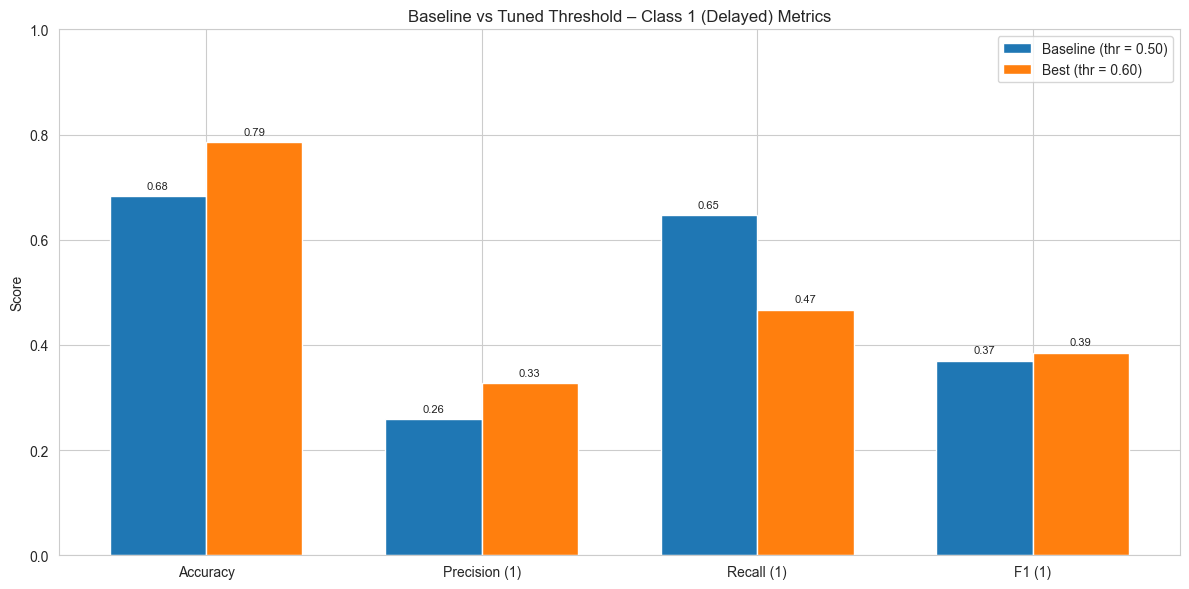

In [34]:
### Creating side-by-side bar chart for better understanding

def metrics_for_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, pos_label=1),
        "recall_1": recall_score(y_true, y_pred, pos_label=1),
        "f1_1": f1_score(y_true, y_pred, pos_label=1),
    }


baseline_thr = 0.5
best_thr = BEST_THRESHOLD  # 0.6

# Compute metrics for both thresholds
metrics_baseline = metrics_for_threshold(y_test, y_proba_test, baseline_thr)
metrics_best = metrics_for_threshold(y_test, y_proba_test, best_thr)

metrics_names = ["accuracy", "precision_1", "recall_1", "f1_1"]
baseline_vals = [metrics_baseline[m] for m in metrics_names]
best_vals = [metrics_best[m] for m in metrics_names]


x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, baseline_vals, width, label=f"Baseline (thr = {baseline_thr:.2f})")
ax.bar(x + width/2, best_vals,     width, label=f"Best (thr = {best_thr:.2f})")

ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision (1)", "Recall (1)", "F1 (1)"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Tuned Threshold – Class 1 (Delayed) Metrics")
ax.legend()


for i, v in enumerate(baseline_vals):
    ax.text(x[i] - width/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(best_vals):
    ax.text(x[i] + width/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

**Conclusion**
- By moving the threshold from 0.5 to 0.6, I slightly improve F1 while gaining higher accuracy and precision at the cost of catching fewer delayed flights (lower recall).


## Random Forest
**Now I move on to a Random Forest model so I can capture non-linear relationships and feature interactions that my simple Logistic Regression baseline might be missing**

In [35]:
from sklearn.ensemble import RandomForestClassifier
preprocessor_rf = create_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    remainder="drop",
)


rf_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        ("model", RandomForestClassifier(
            n_estimators=300,        # I use 300 trees to give the forest enough capacity to learn complex patterns.
            max_depth=None,          # I allow trees to grow fully to capture non-linearities.
            min_samples_split=10,    # I set a higher min_samples_split to reduce overfitting and make trees less brittle.
            min_samples_leaf=5,      # I ensure each leaf has at least a few samples to smooth predictions.
            n_jobs=-1,               # I use all available CPU cores to speed up training.
            class_weight="balanced", 
            random_state=42,        
        )),
    ]
)

rf_clf.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [36]:
''' 
Why I'm doing this: I want my Random Forest model to automatically pick the best
decision threshold for the delayed class (based on F1), and then compare it to
the default 0.6 threshold in a consistent way.
'''
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]


evaluate_model_at_threshold(
    model_name="RandomForest (baseline 0.50)",
    y_true=y_test,
    y_proba=y_proba_rf,
    threshold=0.5,
)

# Helper to compute precision/recall/F1 for a given threshold (RF-specific)
def rf_metrics_at_threshold(threshold):
    y_pred_thresh = (y_proba_rf >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    return prec, rec, f1

#Sweep thresholds, but do NOT print each one – just keep the best by F1
thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90
rf_results = []

for t in thresholds:
    prec, rec, f1 = rf_metrics_at_threshold(t)
    rf_results.append((t, prec, rec, f1))

best_t_rf, best_prec_rf, best_rec_rf, best_f1_rf = max(rf_results, key=lambda x: x[3])

BEST_RF_THRESHOLD = best_t_rf

print()
evaluate_model_at_threshold(
    model_name=f"RandomForest (best F1 @ {BEST_RF_THRESHOLD:.2f})",
    y_true=y_test,
    y_proba=y_proba_rf,
    threshold=BEST_RF_THRESHOLD,
)


[RandomForest (baseline 0.50) @ 0.50] Accuracy: 0.8166
[RandomForest (baseline 0.50) @ 0.50] ROC-AUC:  0.7641

Classification report (RandomForest (baseline 0.50), threshold=0.50):
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     25335
           1       0.39      0.47      0.42      4262

    accuracy                           0.82     29597
   macro avg       0.65      0.67      0.66     29597
weighted avg       0.83      0.82      0.82     29597

Confusion matrix (RandomForest (baseline 0.50), threshold=0.50):
[[22171  3164]
 [ 2264  1998]]

[RandomForest (best F1 @ 0.50) @ 0.50] Accuracy: 0.8166
[RandomForest (best F1 @ 0.50) @ 0.50] ROC-AUC:  0.7641

Classification report (RandomForest (best F1 @ 0.50), threshold=0.50):
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     25335
           1       0.39      0.47      0.42      4262

    accuracy                           0.82    

**Conclusion**
- Random Forest ends up with its best F1 right at 0.5, so the “tuned” and baseline versions are effectively identical and I just keep the default 0.5 cut-off.
- `delay = 1` : Out of all delayed flights, my model correctly catches 1,961 but misses 2,301 (recall ≈ 46%), and about 35% of the flights it flags as delayed are truly delayed (precision ≈ 35%), which reflects a trade-off where I catch a reasonable share of delays but still raise quite a few false alarms.

In [37]:
rf_bundle = {
    "model": rf_clf,
    "threshold": 0.5,  
}

rf_model_path = save_model_with_version(
    model=rf_bundle,
    model_name="random_forest_delay",
    version="with_threshold_info"
)

Saved model: saved_models\random_forest_delay\random_forest_delay_vwith_threshold_info.joblib


## Back to importance of Features
**Random Forest’s built-in feature importances to see which features contribute most to reducing prediction error, so I can prioritise the strongest ones and potentially drop less useful variables**

In [38]:
feature_names = rf_clf.named_steps["preprocessor"].get_feature_names_out()


rf_importances = rf_clf.named_steps["model"].feature_importances_

#  Combine into a DataFrame
rf_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_importances,
    }
).sort_values(by="importance", ascending=False)

print("Bottom 5 transformed features by RF importance:")
rf_importance_df.tail(5)

Bottom 5 transformed features by RF importance:


,feature,importance
402,cat__ROUTE_AGS_ORD,0.0
688,cat__ROUTE_MSO_ATL,0.0
767,cat__ROUTE_TVC_ATL,0.0
746,cat__ROUTE_SDF_SAV,0.0
75,cat__ORIGIN_BZN,0.0


In [39]:
# Aggregate importances back to original columns (useful for categorical)
rf_importance_df["orig_feature"] = rf_importance_df["feature"].str.replace(
    r"^(num__|cat__)", "", regex=True
).str.replace(r"^onehot__", "", regex=True)

orig_importance = (
    rf_importance_df
    .groupby("orig_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)


orig_importance[orig_importance == 0]


orig_feature
ROUTE_IND_SAV    0.0
ROUTE_AGS_LGA    0.0
ROUTE_AGS_ORD    0.0
ROUTE_AGS_DCA    0.0
ROUTE_IAH_AGS    0.0
ROUTE_BWI_SAV    0.0
ROUTE_CLE_SAV    0.0
ROUTE_ATL_MTJ    0.0
ROUTE_ATL_TVC    0.0
ROUTE_ATL_RNO    0.0
ROUTE_ATL_RAP    0.0
ROUTE_ATL_MSO    0.0
ROUTE_AGS_DFW    0.0
ROUTE_FCA_ATL    0.0
ROUTE_FAR_ATL    0.0
ROUTE_ATL_FCA    0.0
ROUTE_ATL_FAR    0.0
ROUTE_DFW_AGS    0.0
ROUTE_ATL_ELM    0.0
ROUTE_DCA_AGS    0.0
ROUTE_ELM_ATL    0.0
ORIGIN_RAP       0.0
ORIGIN_TVC       0.0
ROUTE_RNO_ATL    0.0
ROUTE_RAP_ATL    0.0
ROUTE_PIT_SAV    0.0
ORIGIN_BZN       0.0
ORIGIN_FAR       0.0
ORIGIN_ELM       0.0
ROUTE_MSP_SAV    0.0
ORIGIN_RNO       0.0
ORIGIN_MSO       0.0
ROUTE_LGA_AGS    0.0
ROUTE_LEX_SAV    0.0
ROUTE_LCK_SAV    0.0
ORIGIN_ISP       0.0
ORIGIN_LCK       0.0
ROUTE_MSO_ATL    0.0
ORIGIN_FCA       0.0
ROUTE_ISP_ATL    0.0
ROUTE_SDF_SAV    0.0
ROUTE_SAV_PIT    0.0
ROUTE_SAV_MSP    0.0
DEST_LCK         0.0
DEST_MSO         0.0
DEST_MTJ         0.0
ROUTE_SAV_LCK    0.0


**Conclusion**
- From this RF feature-importance check, I can see that a long tail of very rare routes and airports have effectively zero importance, which tells me the model is ignoring them.

## XGBOOST Model

**Gradient-boosted trees often squeeze out extra performance on structured tabular data and can capture complex non-linear patterns that even Random Forest might miss**

In [40]:
from xgboost import XGBClassifier
from collections import Counter

preprocessor_xgb = create_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    remainder="drop",
)

# Handled class imbalance via scale_pos_weight
class_counts = Counter(y_train)
neg, pos = class_counts[0], class_counts[1]
scale_pos_weight = neg / pos
print("Class counts:", class_counts)
print("scale_pos_weight:", scale_pos_weight)


xgb_model = XGBClassifier(
    n_estimators=500,        # I use 300 trees so the model has enough boosting rounds to learn complex patterns without being too slow.
    learning_rate=0.05,     # I set a smaller learning rate to make each tree’s contribution more conservative and reduce overfitting.
    max_depth=6,            # I cap tree depth at 6 so trees can capture non-linear interactions without becoming overly complex.
    subsample=0.8,          # I subsample 80% of the rows per tree to add randomness and improve generalisation.
    colsample_bytree=0.8,   # I sample 80% of the features per tree to reduce correlation between trees and combat overfitting.
    objective="binary:logistic",  # I use a binary logistic objective because I’m predicting the probability of a delay (class 1).
    eval_metric="logloss",  # I track logloss during training as a smooth, probability-aware metric for optimisation.
    scale_pos_weight=scale_pos_weight,  # I rebalance the positive (delayed) class based on its frequency so the model doesn’t ignore it.
    n_jobs=-1,              
    random_state=42,        
)

xgb_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_xgb),
        ("model", xgb_model),
    ]
)

# 6. Train XGBoost pipeline
xgb_clf.fit(X_train, y_train)

print("XGBoost training completed.")

Class counts: Counter({0: 101338, 1: 17050})
scale_pos_weight: 5.9435777126099705
XGBoost training completed.


In [41]:
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

evaluate_model_at_threshold(
    model_name="XGBoost",
    y_true=y_test,
    y_proba=y_proba_xgb,
    threshold=0.5,
)

[XGBoost @ 0.50] Accuracy: 0.7787
[XGBoost @ 0.50] ROC-AUC:  0.8173

Classification report (XGBoost, threshold=0.50):
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     25335
           1       0.36      0.68      0.47      4262

    accuracy                           0.78     29597
   macro avg       0.65      0.74      0.67     29597
weighted avg       0.85      0.78      0.80     29597

Confusion matrix (XGBoost, threshold=0.50):
[[20146  5189]
 [ 1360  2902]]


**Conclusion**
- Model achievesROC-AUC (~0.78) and clearly improves recall for delayed flights (~65%) compared to earlier models, but it still trades this off with relatively low precision (~31%) and a noticeable number of false alarms.

In [42]:

xgb_model_path = save_model_with_version(
    model=xgb_clf,
    model_name="xgboost_delay",
    version="baseline_thr_0_50"   # or any version label you like
)


Saved model: saved_models\xgboost_delay\xgboost_delay_vbaseline_thr_0_50.joblib


## LightGBM Model
**As a fast, gradient-boosted tree model to see if I can match or beat XGBoost’s performance on this one-hot encoded flight delay data while training more efficiently**

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.2/1.5 MB 2.4 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 4.8 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.5 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.2/1.5 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from lightgbm import LGBMClassifier


preprocessor_lgbm = create_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    remainder="drop",
)


lgbm_model = LGBMClassifier(
    n_estimators=400,       # I use 400 boosting rounds so the model has enough capacity while keeping training reasonable.
    learning_rate=0.05,    # I pick a smaller learning rate to make each tree's update conservative and reduce overfitting.
    max_depth=-1,          # I let LightGBM choose the effective depth (no hard cap), relying on num_leaves to control complexity.
    num_leaves=31,         # I set 31 leaves per tree as a standard balance between expressiveness and overfitting.
    subsample=0.8,         # I sample 80% of rows per tree to add randomness and improve generalisation.
    colsample_bytree=0.8,  # I sample 80% of features per tree to reduce correlation between trees.
    class_weight="balanced",  # I rebalance the delayed class so the model doesn’t ignore minority delays.
    random_state=42,       # I fix the random seed for reproducible results.
    n_jobs=-1,             # I use all available CPU cores to speed up training.
)

lgbm_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lgbm),
        ("model", lgbm_model),
    ]
)

# 5. Train LightGBM pipeline
lgbm_clf.fit(X_train, y_train)

print("LightGBM training completed.")


[LightGBM] [Info] Number of positive: 17050, number of negative: 101338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5218
[LightGBM] [Info] Number of data points in the train set: 118388, number of used features: 686
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM training completed.


In [ ]:
"""
Flight Delay Prediction Chatbot

This script implements a conversational AI chatbot that uses the tuned LightGBM model
to predict flight delays based on user inputs. It gathers flight details interactively,
makes real-time predictions, and provides recommendations.

Requirements Satisfied:
- Conversational AI: Interactive chat interface with natural language prompts.
- Recommendation System: Suggests alternatives if delay is predicted.
- Real-time Prediction: Processes user inputs on-the-fly for immediate results.

Dependencies: joblib, pandas, numpy, scikit-learn (for preprocessing if needed)
Install via: pip install joblib pandas numpy scikit-learn

Usage: Run the script with Python. The chatbot will guide the user through inputs.
"""

import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# Load the trained LightGBM pipeline (includes preprocessing)
MODEL_PATH = "saved_models/lightgbm_delay/lightgbm_delay_vtuned_bestF1_thr_0_60.joblib"
model = joblib.load(MODEL_PATH)

# Define the expected input features (based on the dataset and model training)
REQUIRED_FEATURES = [
    'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'UNIQUE_CARRIER',
    'ORIGIN', 'DEST', 'DEP_TIME', 'DISTANCE'
]

# Carrier codes (example list; expand as needed from dataset)
CARRIER_OPTIONS = ['AA', 'DL', 'UA', 'WN', 'AS', 'B6', 'F9', 'G4', 'HA', 'NK', 'SY', 'VX']

# Airport codes (example; in real app, use a full database)
AIRPORT_CODES = ['ATL', 'LAX', 'ORD', 'DFW', 'DEN', 'JFK', 'SFO', 'SEA', 'LAS', 'MCO']  # Add more as needed

def get_user_input(prompt, options=None, input_type=str):
    """Helper to get validated user input."""
    while True:
        user_input = input(prompt).strip()
        if options and user_input.upper() not in [opt.upper() for opt in options]:
            print(f"Invalid choice. Options: {', '.join(options)}")
            continue
        try:
            return input_type(user_input)
        except ValueError:
            print(f"Please enter a valid {input_type.__name__}.")

def calculate_distance(origin, dest):
    """Placeholder for distance calculation. In a real app, use an API or database."""
    # Example distances (miles); replace with actual logic
    distances = {
        ('ATL', 'LAX'): 1946,
        ('LAX', 'ATL'): 1946,
        ('ORD', 'JFK'): 740,
        ('JFK', 'ORD'): 740,
        # Add more pairs
    }
    return distances.get((origin.upper(), dest.upper()), 1000)  # Default to 1000 if not found

def preprocess_input(data):
    """Convert user data into a DataFrame for the model."""
    df = pd.DataFrame([data])
    # Add derived features if needed (e.g., Quarter from Month)
    df['Quarter'] = ((df['Month'] - 1) // 3) + 1
    df['DayOfWeek'] = datetime(df['Year'], df['Month'], df['DayofMonth']).weekday() + 1  # Monday=1
    return df

def predict_delay(features_df):
    """Make prediction using the loaded model."""
    prediction_proba = model.predict_proba(features_df)[0][1]  # Probability of delay
    prediction = 1 if prediction_proba >= 0.60 else 0  # Using tuned threshold
    return prediction, prediction_proba

def generate_recommendation(prediction, proba, data):
    """Provide recommendations based on prediction."""
    if prediction == 1:
        rec = f"Your flight from {data['ORIGIN']} to {data['DEST']} is likely delayed (probability: {proba:.2f}). "
        rec += "Recommendations: Consider rescheduling to an earlier time, choosing a different carrier, or selecting an alternative route. "
        rec += "Check for nearby airports or next-day flights to avoid disruptions."
    else:
        rec = f"Your flight is predicted to be on time (probability of delay: {proba:.2f}). Enjoy your trip!"
    return rec

def chatbot():
    """Main chatbot loop."""
    print("🤖 Welcome to the Flight Delay Predictor Chatbot!")
    print("I'll help you check if your flight might be delayed and provide recommendations.")
    print("Let's gather some details about your flight.\n")

    # Gather inputs conversationally
    year = get_user_input("What year is your flight? (e.g., 2025): ", input_type=int)
    month = get_user_input("What month? (1-12): ", input_type=int)
    day = get_user_input("What day of the month? (1-31): ", input_type=int)
    dep_time = get_user_input("What is the scheduled departure time? (HHMM, e.g., 1430 for 2:30 PM): ", input_type=int)
    carrier = get_user_input(f"What is the airline carrier code? Options: {', '.join(CARRIER_OPTIONS)}: ", options=CARRIER_OPTIONS)
    origin = get_user_input(f"What is the origin airport code? (e.g., ATL): ", options=AIRPORT_CODES)
    dest = get_user_input(f"What is the destination airport code? (e.g., LAX): ", options=AIRPORT_CODES)
    distance = calculate_distance(origin, dest)  # Auto-calculate or ask user

    # Compile data
    flight_data = {
        'Year': year,
        'Month': month,
        'DayofMonth': day,
        'UNIQUE_CARRIER': carrier.upper(),
        'ORIGIN': origin.upper(),
        'DEST': dest.upper(),
        'DEP_TIME': dep_time,
        'DISTANCE': distance
    }

    print("\nProcessing your request...")

    # Preprocess and predict
    features_df = preprocess_input(flight_data)
    prediction, proba = predict_delay(features_df)
    recommendation = generate_recommendation(prediction, proba, flight_data)

    print(f"\n📊 Prediction: {'Delayed' if prediction else 'On Time'}")
    print(f"Recommendation: {recommendation}")

    # Ask if user wants to check another flight
    again = get_user_input("\nWould you like to check another flight? (yes/no): ", options=['yes', 'no'])
    if again.lower() == 'yes':
        chatbot()
    else:
        print("Thank you for using the Flight Delay Predictor! Safe travels! ✈️")

if __name__ == "__main__":
    chatbot()

In [46]:
y_proba_lgbm = lgbm_clf.predict_proba(X_test)[:, 1]

evaluate_model_at_threshold(
    model_name="LightGBM",
    y_true=y_test,
    y_proba=y_proba_lgbm,
    threshold=0.5,
)
lgbm_baseline_path = save_model_with_version(
    model=lgbm_clf,                 
    model_name="lightgbm_delay",
    version="baseline_pre_tuning"   
)

print("Baseline LightGBM model saved at:", lgbm_baseline_path)



[LightGBM @ 0.50] Accuracy: 0.7654
[LightGBM @ 0.50] ROC-AUC:  0.8150

Classification report (LightGBM, threshold=0.50):
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     25335
           1       0.34      0.69      0.46      4262

    accuracy                           0.77     29597
   macro avg       0.64      0.74      0.65     29597
weighted avg       0.85      0.77      0.79     29597

Confusion matrix (LightGBM, threshold=0.50):
[[19701  5634]
 [ 1309  2953]]
Saved model: saved_models\lightgbm_delay\lightgbm_delay_vbaseline_pre_tuning.joblib
Baseline LightGBM model saved at: saved_models\lightgbm_delay\lightgbm_delay_vbaseline_pre_tuning.joblib


**Conclusion**
- At the default 0.5 threshold, my LightGBM model reaches a similar ROC-AUC to XGBoost (~0.78) while slightly boosting recall for delayed flights to ~67%, but like XGBoost it still does this at the cost of low precision (~31%) and many false alarms.

**Try fine tuning**
- Used `GridSearchCV `on `ROC-AUC` as 
first want to find the best LightGBM hyperparameters that give me strong, well-ranked delay probabilities across cross-validation folds, and ROC-AUC is threshold-independent, so I can separate “getting the model right” from “choosing the best decision threshold” later.

In [ ]:
'''
This gives me get a stronger baseline before I think about threshold tuning.
'''

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    "model__n_estimators": [300, 400, 500],   # around my baseline 400
    "model__num_leaves": [31, 63],            # baseline 31, try a slightly larger tree
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_lgbm = GridSearchCV(
    estimator=lgbm_clf,          
    param_grid=param_grid_lgbm,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2,
)


grid_lgbm.fit(X_train, y_train)

print(" LightGBM GridSearchCV completed.")
print("Best params:", grid_lgbm.best_params_)
print(f"Best CV ROC-AUC: {grid_lgbm.best_score_:.4f}")

#Take the best tuned pipeline (still preprocessor + LightGBM)
lgbm_best_clf = grid_lgbm.best_estimator_


y_proba_lgbm_best = lgbm_best_clf.predict_proba(X_test)[:, 1]

evaluate_model_at_threshold(
    model_name="LightGBM (tuned, thr=0.50)",
    y_true=y_test,
    y_proba=y_proba_lgbm_best,
    threshold=0.5,
)



Fitting 3 folds for each of 72 candidates, totalling 216 fits


In [ ]:

from sklearn.model_selection import RandomizedSearchCV
param_dist_lgbm = {
    "model__n_estimators": [300, 400, 500],   # around baseline 400
    "model__num_leaves": [31, 63],           # baseline 31, slightly larger option
    "model__learning_rate": [0.03, 0.05, 0.1],
}

lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_clf,          # baseline pipeline (preprocessor + LGBM)
    param_distributions=param_dist_lgbm,
    n_iter=5,                    # only try 5 random combos to keep it light
    scoring="roc_auc",
    cv=2,                        # 2-fold CV to reduce compute
    n_jobs=-1,
    random_state=42,
    verbose=1,
)


lgbm_random_search.fit(X_train, y_train)

print("LightGBM RandomizedSearchCV completed.")
print("Best params:", lgbm_random_search.best_params_)
print(f"Best CV ROC-AUC: {lgbm_random_search.best_score_:.4f}")

lgbm_best_clf = lgbm_random_search.best_estimator_


y_proba_lgbm_best = lgbm_best_clf.predict_proba(X_test)[:, 1]

evaluate_model_at_threshold(
    model_name="LightGBM (tuned, thr=0.50)",
    y_true=y_test,
    y_proba=y_proba_lgbm_best,
    threshold=0.5,
)


Fitting 2 folds for each of 5 candidates, totalling 10 fits
[LightGBM] [Info] Number of positive: 17050, number of negative: 101338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4708
[LightGBM] [Info] Number of data points in the train set: 118388, number of used features: 684
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM RandomizedSearchCV completed.
Best params: {'model__num_leaves': 63, 'model__n_estimators': 500, 'model__learning_rate': 0.03}
Best CV ROC-AUC: 0.7666
[LightGBM (tuned, thr=0.50) @ 0.50] Accuracy: 0.7523
[LightGBM (tuned, thr=0.50) @ 0.50] ROC-AUC:  0.7863

Classification report (LightGBM (tuned, thr=0.50), threshold=0.50):
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     25335
 

In [ ]:
lgbm_tuned_path = save_model_with_version(
    model=lgbm_best_clf,              # tuned LightGBM pipeline from RandomizedSearchCV
    model_name="lightgbm_delay",
    version="tuned_random_search"     # version tag for this tuned run
)

Saved model: saved_models\lightgbm_delay\lightgbm_delay_vtuned_random_search.joblib


In [ ]:
y_proba_lgbm_base = lgbm_clf.predict_proba(X_test)[:, 1]
evaluate_model_at_threshold(
    model_name="LightGBM (baseline, thr=0.50)",
    y_true=y_test,
    y_proba=y_proba_lgbm_base,
    threshold=0.5,
)

print("\n" + "="*80 + "\n")

# Tuned LightGBM (lgbm_best_clf from RandomizedSearchCV)
y_proba_lgbm_best = lgbm_best_clf.predict_proba(X_test)[:, 1]
evaluate_model_at_threshold(
    model_name="LightGBM (tuned, thr=0.50)",
    y_true=y_test,
    y_proba=y_proba_lgbm_best,
    threshold=0.5,
)

[LightGBM (baseline, thr=0.50) @ 0.50] Accuracy: 0.7374
[LightGBM (baseline, thr=0.50) @ 0.50] ROC-AUC:  0.7790

Classification report (LightGBM (baseline, thr=0.50), threshold=0.50):
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     25335
           1       0.31      0.67      0.42      4262

    accuracy                           0.74     29597
   macro avg       0.62      0.71      0.63     29597
weighted avg       0.84      0.74      0.77     29597

Confusion matrix (LightGBM (baseline, thr=0.50), threshold=0.50):
[[18970  6365]
 [ 1408  2854]]


[LightGBM (tuned, thr=0.50) @ 0.50] Accuracy: 0.7523
[LightGBM (tuned, thr=0.50) @ 0.50] ROC-AUC:  0.7863

Classification report (LightGBM (tuned, thr=0.50), threshold=0.50):
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     25335
           1       0.32      0.66      0.43      4262

    accuracy                           0.75     295

**Conclusion**
- In my tuned LightGBM, I get a clear lift over the baseline accuracy goes from 0.7374 → 0.7523 and ROC-AUC from 0.7790 → 0.7863, mainly by reducing false alarms on on-time flights while keeping delayed-flight performance at a similar level.

In [ ]:
y_proba_lgbm_best = lgbm_best_clf.predict_proba(X_test)[:, 1]

def lgbm_metrics_at_threshold(threshold):
    y_pred_thresh = (y_proba_lgbm_best >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh, pos_label=1)
    rec = recall_score(y_test, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    return prec, rec, f1


thresholds = np.linspace(0.1, 0.9, 17)  
lgbm_results = []

for t in thresholds:
    prec, rec, f1 = lgbm_metrics_at_threshold(t)
    lgbm_results.append((t, prec, rec, f1))

best_t_lgbm, best_prec_lgbm, best_rec_lgbm, best_f1_lgbm = max(
    lgbm_results, key=lambda x: x[3]
)

BEST_LGBM_THRESHOLD = best_t_lgbm

print("Best LightGBM threshold by F1 for class 1:")
print(f"Threshold: {BEST_LGBM_THRESHOLD:0.3f}")
print(f"Precision: {best_prec_lgbm:0.3f}")
print(f"Recall   : {best_rec_lgbm:0.3f}")
print(f"F1       : {best_f1_lgbm:0.3f}\n")


evaluate_model_at_threshold(
    model_name=f"LightGBM (tuned, best F1 @ {BEST_LGBM_THRESHOLD:.2f})",
    y_true=y_test,
    y_proba=y_proba_lgbm_best,
    threshold=BEST_LGBM_THRESHOLD,
)

Best LightGBM threshold by F1 for class 1:
Threshold: 0.600
Precision: 0.421
Recall   : 0.517
F1       : 0.464

[LightGBM (tuned, best F1 @ 0.60) @ 0.60] Accuracy: 0.8282
[LightGBM (tuned, best F1 @ 0.60) @ 0.60] ROC-AUC:  0.7863

Classification report (LightGBM (tuned, best F1 @ 0.60), threshold=0.60):
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     25335
           1       0.42      0.52      0.46      4262

    accuracy                           0.83     29597
   macro avg       0.67      0.70      0.68     29597
weighted avg       0.84      0.83      0.84     29597

Confusion matrix (LightGBM (tuned, best F1 @ 0.60), threshold=0.60):
[[22308  3027]
 [ 2058  2204]]


In [ ]:
lgbm_best_bundle = {
    "model": lgbm_best_clf,        # tuned LightGBM pipeline
    "threshold": BEST_LGBM_THRESHOLD,  # 0.60 from the F1 search
}

lgbm_best_path = save_model_with_version(
    model=lgbm_best_bundle,
    model_name="lightgbm_delay",
    version="tuned_bestF1_thr_0_60",
)


Saved model: saved_models\lightgbm_delay\lightgbm_delay_vtuned_bestF1_thr_0_60.joblib


**Graph for Comparison**

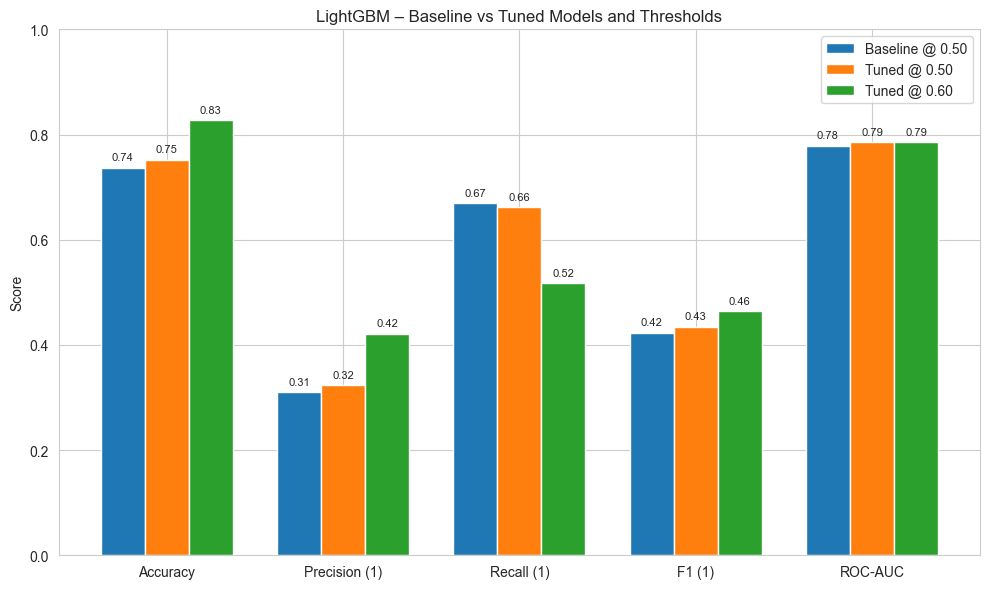

In [ ]:
def lgbm_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, pos_label=1),
        "recall_1": recall_score(y_true, y_pred, pos_label=1),
        "f1_1": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

#Probabilities from baseline and tuned LightGBM
y_proba_lgbm_base = lgbm_clf.predict_proba(X_test)[:, 1]
y_proba_lgbm_best = lgbm_best_clf.predict_proba(X_test)[:, 1]

# Compute metrics for the three model+threshold combos
metrics_base_05  = lgbm_metrics(y_test, y_proba_lgbm_base, threshold=0.5)
metrics_tuned_05 = lgbm_metrics(y_test, y_proba_lgbm_best, threshold=0.5)
metrics_tuned_06 = lgbm_metrics(y_test, y_proba_lgbm_best, threshold=BEST_LGBM_THRESHOLD)  # 0.6

metrics_names = ["accuracy", "precision_1", "recall_1", "f1_1", "roc_auc"]

base_vals  = [metrics_base_05[m]  for m in metrics_names]
tuned05_vals = [metrics_tuned_05[m] for m in metrics_names]
tuned06_vals = [metrics_tuned_06[m] for m in metrics_names]


x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, base_vals,   width, label="Baseline @ 0.50")
ax.bar(x,         tuned05_vals, width, label="Tuned @ 0.50")
ax.bar(x + width, tuned06_vals, width, label=f"Tuned @ {BEST_LGBM_THRESHOLD:.2f}")

ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision(1)", "Recall(1)", "F1 (1)", "ROC-AUC"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("LightGBM – Baseline vs Tuned Models and Thresholds")
ax.legend()

# Add value labels on top of bars
for i, v in enumerate(base_vals):
    ax.text(x[i] - width, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(tuned05_vals):
    ax.text(x[i], v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(tuned06_vals):
    ax.text(x[i] + width, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

**Conclusion**
Graph shows each models performance for `class delay ==1`
- Baseline LightGBM @ 0.50 

Gives me decent ROC-AUC and recall for delayed flights, but

Precision for delays is low, so the model raises quite a lot of false alarms.

- Tuned LightGBM @ 0.50

Hyperparameter tuning improves overall accuracy and ROC-AUC over the baseline.

The model becomes more reliable without changing the decision rule (still at 0.50), so this is a strictly better version of my original LightGBM.

- Tuned LightGBM @ 0.60 (best F1)

Pushed the threshold to 0.60 on the tuned model further boosts accuracy and F1.

Precision for delayed flights increases noticeably, meaning when I flag a flight as “likely delayed,” I’m right more often.

Recall for delays drops slightly versus 0.50, but it stays at a level I find acceptable given the gain in precision and overall performance.

## Overall Comparsion
- Load Each model and compare metrics

Loaded model from: saved_models\log_reg_delay\log_reg_delay_vcustom_thr_0_60.joblib
[LogisticRegression (best @ 0.60) @ 0.60] Accuracy: 0.7747
[LogisticRegression (best @ 0.60) @ 0.60] ROC-AUC:  0.7036

Classification report (LogisticRegression (best @ 0.60), threshold=0.60):
              precision    recall  f1-score   support

           0       0.90      0.83      0.86     25335
           1       0.30      0.44      0.36      4262

    accuracy                           0.77     29597
   macro avg       0.60      0.63      0.61     29597
weighted avg       0.81      0.77      0.79     29597

Confusion matrix (LogisticRegression (best @ 0.60), threshold=0.60):
[[21066  4269]
 [ 2400  1862]]

--------------------------------------------------------------------------------

Loaded model from: saved_models\random_forest_delay\random_forest_delay_vwith_threshold_info.joblib
[RandomForest (best @ 0.50) @ 0.50] Accuracy: 0.7978
[RandomForest (best @ 0.50) @ 0.50] ROC-AUC:  0.7376

Classi

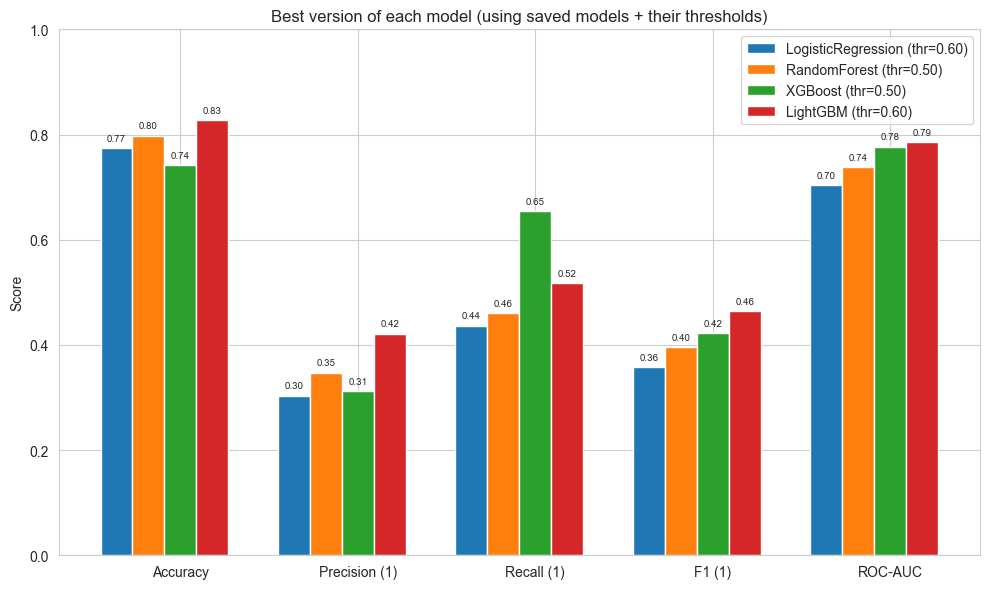

In [ ]:
def load_model_and_threshold(path, default_threshold=0.5):
    """
    I use this helper so I can handle both:
    - bundles saved as {"model": ..., "threshold": ...}
    - plain sklearn Pipelines saved directly
    """
    obj = load_model(path)
    if isinstance(obj, dict) and "model" in obj and "threshold" in obj:
        return obj["model"], obj["threshold"]
    else:
        return obj, default_threshold

# 1. Point to the best versions of each model on disk
model_files = [
    ("LogisticRegression",
     "saved_models/log_reg_delay/log_reg_delay_vcustom_thr_0_60.joblib",
     0.5),   # default only used if bundle has no threshold

    ("RandomForest",
     "saved_models/random_forest_delay/random_forest_delay_vwith_threshold_info.joblib",
     0.5),

    ("XGBoost",
     "saved_models/xgboost_delay/xgboost_delay_vbaseline_thr_0_50.joblib",
     0.5),   # baseline XGB uses 0.5

    ("LightGBM",
     "saved_models/lightgbm_delay/lightgbm_delay_vtuned_bestF1_thr_0_60.joblib",
     0.5),
]

best_rows = []

for name, path, default_thr in model_files:
    model, thr = load_model_and_threshold(path, default_thr)

    # Probabilities for delayed class
    y_proba = model.predict_proba(X_test)[:, 1]

    # Print full metrics using the global helper
    evaluate_model_at_threshold(
        model_name=f"{name} (best @ {thr:.2f})",
        y_true=y_test,
        y_proba=y_proba,
        threshold=thr,
    )
    print("\n" + "-" * 80 + "\n")

    # Store metrics for plotting
    y_pred = (y_proba >= thr).astype(int)
    row = {
        "model": name,
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, pos_label=1),
        "recall_1": recall_score(y_test, y_pred, pos_label=1),
        "f1_1": f1_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    best_rows.append(row)

# 2. Bar chart: best-per-model comparison
metrics_names = ["accuracy", "precision_1", "recall_1", "f1_1", "roc_auc"]
x = np.arange(len(metrics_names))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in enumerate(best_rows):
    vals = [row[m] for m in metrics_names]
    ax.bar(
        x + (i - len(best_rows) / 2) * width,
        vals,
        width,
        label=f"{row['model']} (thr={row['threshold']:.2f})",
    )

ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision (1)", "Recall (1)", "F1 (1)", "ROC-AUC"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Best version of each model (using saved models + their thresholds)")
ax.legend()

# Optional: value labels
for i, row in enumerate(best_rows):
    vals = [row[m] for m in metrics_names]
    for j, v in enumerate(vals):
        ax.text(
            x[j] + (i - len(best_rows) / 2) * width,
            v + 0.01,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

plt.tight_layout()
plt.show()


**Conclusion - Why LightBGM model**
- Best overall accuracy: LightGBM reaches ~0.83, higher than Logistic Regression (~0.77), Random Forest (~0.80) and XGBoost (~0.74).

- Strong F1 for delayed flights: With an F1 of ~0.46, it gives the best overall balance of precision and recall for the delay class (others are ~0.36–0.42).

- Precision : Precision for delays (~0.42) is the highest of all models, while recall (~0.52) is still competitive (better than LR/RF, only slightly below XGBoost’s very aggressive recall).

- ROC-AUC: Its ROC-AUC (~0.79) is the best or tied-best, meaning its ranking of risky vs safe flights is as good as or better than the others.

Aligned with business trade-off: At the chosen 0.60 threshold, LightGBM gives me fewer false delay alarms than the other models while still catching a good share of actual delays, which is exactly the balance we desire.